# 03 — Tier A: scalar features from the calcium trace

**What this notebook does.** Computes the 20 Tier-A scalar features
(WORKFLOW §4) on every trace cached in notebook 02:

- **A-amp (10 features)** — *how strong* and *how dispersed* the response is.
- **A-shape (10 features)** — *how the response unfolds in time*.

These same 20 functions are applied at two granularities:

- **Tier A0** — per `(nucleus_id, trial_idx)` from `traces.parquet`
  (≈ 4.13M rows). Single noisy realisation of the stimulus-locked response.
- **Tier A1** — per `(nucleus_id, condition_hash)` from `traces_avg.parquet`
  (≈ 2.49M rows). Within-hash trial-averaged trace — cleaner stimulus-locked
  estimator (WORKFLOW §3.3).

Tier A1 features are **not** averages of Tier A0 features across trials of
a hash. The trace is averaged first; *then* features are computed on the
averaged trace. WORKFLOW §4 A1 is explicit about this and we follow it.

**Reads.**
- `data/processed/tables/traces.parquet`
- `data/processed/tables/traces_avg.parquet`
- `data/processed/tables/units_working.parquet`

**Writes (under `data/processed/features/`).**
- `A0_amp.parquet`   — 10 amplitude features per `(nucleus_id, trial_idx)`
- `A0_shape.parquet` — 10 shape features per `(nucleus_id, trial_idx)`
- `A1_amp.parquet`   — 10 amplitude features per `(nucleus_id, condition_hash)`
- `A1_shape.parquet` — 10 shape features per `(nucleus_id, condition_hash)`

Splitting amp from shape is deliberate: WORKFLOW §5 Stage 1's sub-ablation
is *amp-only vs amp + shape*, which becomes a column-set toggle when the
two blocks are stored in separate files.

**Methodological notes (binding from WORKFLOW.md).**
- §3.5: no precomputed tuning parameters, no orientation features. Tier A
  consumes the calcium trace only.
- §3.3: across-hash averaging is forbidden as a feature step. Trial-
  averaging happened in notebook 02, within-hash only.
- The PCA-component option for A-shape is CV-aware (must be fit on
  training neurons only). It is therefore deferred to the modelling
  notebook (04), not pre-computed here.

## 1. Setup

In [1]:
from __future__ import annotations

import sys, time, gc
from pathlib import Path

if '..' not in sys.path:
    sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    PROCESSED_DIR, PROCESSED_TABLES_DIR, PROCESSED_FEATURES_DIR,
    FIGURES_DIR, RANDOM_SEED, STIMULUS_FAMILIES,
    ensure_dirs,
)
from src.features.tier_a import (
    AMP_FEATURE_NAMES, SHAPE_FEATURE_NAMES, ALL_FEATURE_NAMES,
    CALCIUM_SAMPLING_RATE_HZ,
    batch_amplitude_features, batch_shape_features,
)

ensure_dirs()
np.random.seed(RANDOM_SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('cwd                   :', Path.cwd())
print('PROCESSED_FEATURES_DIR:', PROCESSED_FEATURES_DIR)
print('sampling rate         :', CALCIUM_SAMPLING_RATE_HZ, 'Hz')
print('# amp features        :', len(AMP_FEATURE_NAMES))
print('# shape features      :', len(SHAPE_FEATURE_NAMES))
print('total per row         :', len(ALL_FEATURE_NAMES))

cwd                   : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
PROCESSED_FEATURES_DIR: data/processed/features
sampling rate         : 7.5 Hz
# amp features        : 10
# shape features      : 10
total per row         : 20


## 2. Feature definitions

Each feature is computed from one calcium trace. Trace lengths are 75
frames (Clip, 10 s) or 113 frames (Monet2 / Trippy, 15 s) at 7.5 Hz. The
trace covers the **stimulus window only** — there is no pre-stim or
post-stim buffer in the H5. Values are **deconvolved activity**:
non-negative, zero-floored, sparse with occasional large spikes.

### A-amp — amplitude / statistical (10 features)

Feature names quoted in `code` font are the column names in the saved
parquets.

- `amp_baseline_mean` — mean of the **first 1 s** of the trace (≈ 8 frames
  at 7.5 Hz). Faithful re-interpretation of WORKFLOW's *pre-stim baseline*
  given that the trace is the stim window (no pre-stim buffer).
- `amp_baseline_std` — std of the same first-1-s window. Captures whether
  the early window is quiet (low std) or already firing.
- `amp_mean` — mean of the full trace. WORKFLOW's *mean during stimulus*.
- `amp_peak` — max of the trace. WORKFLOW's *peak response*.
- `amp_min` — min of the trace. On deconvolved activity this is usually 0;
  kept as a sanity / dynamic-range column.
- `amp_range` — `amp_peak − amp_baseline_mean`. The response amplitude
  *above baseline*. Equivalent to a pseudo-ΔF/F if `baseline_mean > 0`.
- `amp_integral` — sum of the trace. Equivalent to `mean × n_frames`,
  the area-under-the-curve / total response.
- `amp_tail_mean` — mean of the **last 1 s** of the trace. Faithful
  re-interpretation of WORKFLOW's *post-stim tail*.
- `amp_variance` — variance of the trace.
- `amp_std` — std of the trace (= √variance). Both are kept for readability;
  trees treat them as equivalent.

### A-shape — temporal shape (10 features)

All temporal quantities are in **seconds** (or fractional positions for
AUCs and quartiles), so Clip (10 s) and Monet2/Trippy (15 s) features
live on the same axis cross-family.

- `shape_latency_s` — time of the peak in seconds. WORKFLOW's *time-to-peak*.
- `shape_peak_frame_idx` — same in integer frames; redundant but explicit.
- `shape_rise_slope` — `(amp_peak − amp_baseline_mean) / shape_latency_s`,
  units trace-units / s. WORKFLOW's *rise slope from baseline to peak*.
  NaN if the peak is at frame 0 (latency = 0, slope undefined).
- `shape_decay_slope` — `(amp_peak − amp_tail_mean) / (duration − latency)`.
  NaN if the peak is at the last frame.
- `shape_early_auc` — sum over the **first half** of the trace.
- `shape_late_auc` — sum over the **second half** of the trace.
- `shape_early_late_ratio` — `early_auc / late_auc`. NaN if the second-half
  AUC is essentially zero (no signal there).
- `shape_adaptation_ratio` — `last_quartile_mean / first_quartile_mean`.
  WORKFLOW's *adaptation ratio late/early*. < 1 means the response weakens
  over the trace. NaN if the first-quartile mean is essentially zero.
- `shape_center_of_mass_s` — temporal centre of mass: `Σ(t·x) / Σx` in
  seconds. Where the response 'lives' in time. NaN if the trace integral
  is essentially zero.
- `shape_width_above_half_max_s` — duration in seconds where the trace ≥
  peak/2. A FWHM-like measure of how broad the response is. NaN if the
  peak is essentially zero (no signal at all).

### Numerical safety

Edge cases (peak at frame 0, peak at last frame, flat trace, near-zero
denominators) return **NaN**, not `inf`. Each safe-divide uses an absolute,
biologically-sized threshold on the denominator, distinct per quantity:

- `EPS_TRACE    = 1e-6` — raw trace values (used for time-denominators
  in slopes; one-frame granularity at 7.5 Hz is 0.13 s, well above this).
- `EPS_MEAN     = 0.1`  — averaged quantities (e.g. first-quartile mean
  for `shape_adaptation_ratio`).
- `EPS_AUC      = 1.0`  — half-trace sums (`shape_early_late_ratio`'s
  denominator). Half-AUC is typically 25–250 on this data.
- `EPS_INTEGRAL = 1.0`  — full-trace sum (`shape_center_of_mass_s`).
- `EPS_PEAK     = 0.5`  — peak (`shape_width_above_half_max_s`).

Why per-quantity rather than one global epsilon: integrated quantities
(AUC sums) and averaged quantities (means) live on different scales than
raw trace values, so a single 1e-6 threshold lets through 'essentially
zero' denominators of integrated quantities and produces ratios in the
1e+7 range. The values above are calibrated against the empirical feature
distributions to keep ratios bounded by `numerator_max / eps` ≈ ~1000 for
`shape_early_late_ratio` and ~100 for `shape_adaptation_ratio`. NaN counts
rise as a result (more rows are flagged 'denominator too small to define
a ratio'), which is the correct outcome — those rows had no signal to
make a ratio of in the first place.

Tree models that handle NaN natively (HistGradientBoosting, LightGBM)
read NaNs directly. Linear models in the modelling notebook (04) wrap
input in a median imputer.

### What this implementation respects vs what differs from a strict reading of WORKFLOW.md §4

**Respected exactly:**

- Tier A0 vs Tier A1 distinction (per-trial vs per-hash trial-averaged).
- A1 = **trace averaged first, then features** — never average A0 features
  across trials.
- Amp / shape sub-block split (saved as separate parquets for clean
  ablation in Stage 1).
- Cross-family comparability via seconds-and-fractions, not raw frame indices.
- Strict denominator handling (NaN where undefined; never `inf`).
- 10 amp features and 10 shape features (matches the project group's
  expanded enumeration, with PCA components deferred to the modelling
  notebook because the workflow specifies *fit on the training set* and
  that's CV-aware).

**Faithful re-interpretation (and why):**

- *Pre-stim baseline* and *post-stim tail* are computed as the first 1 s
  and last 1 s of the trace. The H5 trace covers the stim window only, so
  these workflow names cannot be 'before stim' or 'after stim'. Documented
  here and in `src/features/tier_a.py`'s docstring.
- No DC subtraction in `amp_mean` / `amp_integral`. The trace is
  deconvolved activity (zero-floored, non-negative); subtracting a
  'baseline' would distort the scale. `amp_range = amp_peak − amp_baseline_mean`
  carries the response amplitude *above* baseline as a separate feature.

## 3. Trace alignment audit (visual)

One trace per stimulus family from session `4_7`, with the windows used
by the feature functions overlaid. Look at where the baseline window, the
tail window, the peak (latency marker), and the early/late split sit in
the trace.

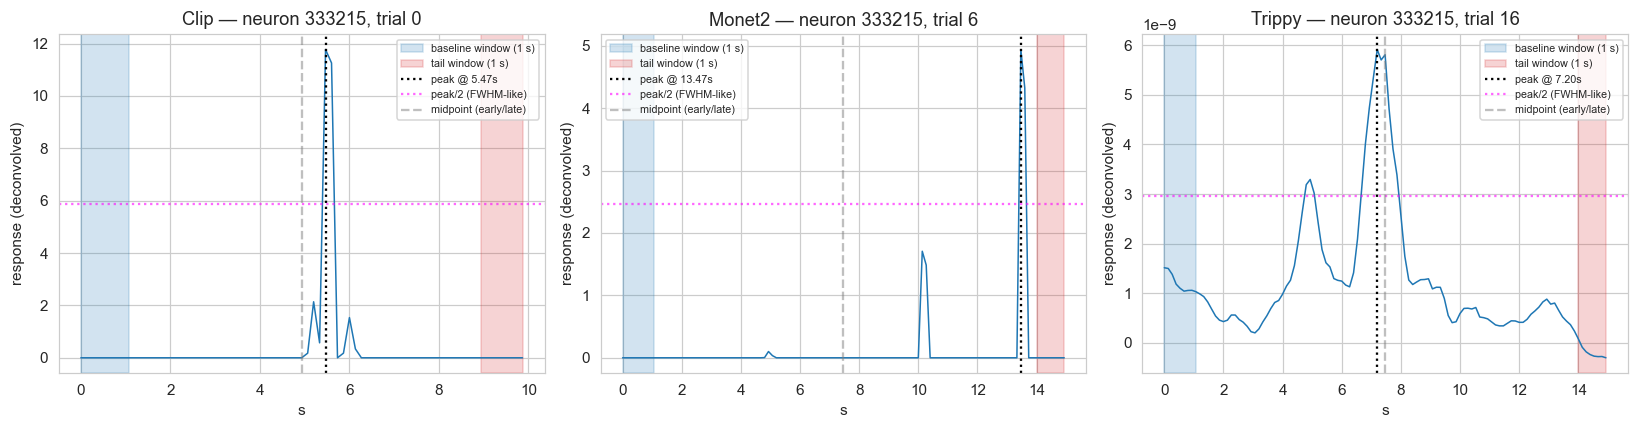

In [2]:
df_trials = pd.read_parquet(PROCESSED_TABLES_DIR / 'trials_meta.parquet',
                            columns=['session_key', 'trial_idx', 'stim_type',
                                     'condition_hash', 'n_frames'])

samples = (df_trials[df_trials['session_key'] == '4_7']
           .drop_duplicates('stim_type', keep='first')
           .set_index('stim_type'))

df_keys = pd.read_parquet(PROCESSED_TABLES_DIR / 'traces.parquet',
                          columns=['nucleus_id', 'session_key', 'trial_idx', 'stim_type'])
neuron_4_7 = df_keys[df_keys['session_key'] == '4_7']['nucleus_id'].iloc[0]
del df_keys; gc.collect()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for i, fam in enumerate(STIMULUS_FAMILIES):
    if fam not in samples.index:
        continue
    s = samples.loc[fam]
    one = pd.read_parquet(PROCESSED_TABLES_DIR / 'traces.parquet',
                          filters=[('nucleus_id', '=', int(neuron_4_7)),
                                   ('session_key', '=', '4_7'),
                                   ('trial_idx',   '=', int(s['trial_idx']))])
    if len(one) == 0:
        continue
    trace = np.asarray(one['response'].iloc[0], dtype=np.float64)
    n = len(trace); t = np.arange(n) / CALCIUM_SAMPLING_RATE_HZ
    n_base = max(1, int(round(1.0 * CALCIUM_SAMPLING_RATE_HZ)))
    ax = axes[i]
    ax.plot(t, trace, lw=1)
    ax.axvspan(0, n_base / CALCIUM_SAMPLING_RATE_HZ, alpha=0.2, color='C0', label='baseline window (1 s)')
    ax.axvspan(t[-n_base], t[-1], alpha=0.2, color='C3', label='tail window (1 s)')
    peak_idx = int(np.argmax(trace))
    ax.axvline(peak_idx / CALCIUM_SAMPLING_RATE_HZ, color='k', ls=':', label=f'peak @ {peak_idx/CALCIUM_SAMPLING_RATE_HZ:.2f}s')
    if trace.max() > 0:
        ax.axhline(trace.max() / 2, color='magenta', ls=':', alpha=0.6, label='peak/2 (FWHM-like)')
    ax.axvline(t[-1] / 2, color='gray', ls='--', alpha=0.5, label='midpoint (early/late)')
    ax.set_title(f'{fam} — neuron {int(neuron_4_7)}, trial {int(s["trial_idx"])}')
    ax.set_xlabel('s'); ax.set_ylabel('response (deconvolved)')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_tierA_alignment.png', dpi=130)
plt.show()

## 4. Compute Tier A0 — per `(nucleus_id, trial_idx)`

Read `traces.parquet`, group by `stim_type` (so every group shares an
`n_frames`), stack the response lists into a 2-D `(N, n_frames)` array,
run the vectorised feature functions, concatenate the groups, save.

Memory: peak ~1.5 GB during the Clip group (~3.4M × 75 float32). The
vectorised feature math itself takes a few seconds; the dominant cost is
the parquet `list<float>` → 2-D ndarray unpack.

In [3]:
TRACES = PROCESSED_TABLES_DIR / 'traces.parquet'
print(f'reading {TRACES} … (1.6 GB; this can take a minute)')
t0 = time.time()
df = pd.read_parquet(TRACES)
print(f'  loaded {len(df):,} rows in {time.time()-t0:.1f}s')

key_cols = ['nucleus_id', 'session_key', 'trial_idx', 'condition_hash',
            'stim_type', 'n_frames']

amp_dfs, shp_dfs = [], []
for fam, fam_df in df.groupby('stim_type', sort=False):
    n_rows = len(fam_df)
    n_frames = int(fam_df['n_frames'].iloc[0])
    print(f'  {fam}: {n_rows:>9,} rows  x  {n_frames} frames  …', flush=True)
    t0 = time.time()
    traces = np.array(fam_df['response'].tolist(), dtype=np.float32)
    print(f'    stacked traces in {time.time()-t0:.1f}s, shape {traces.shape}')
    t0 = time.time()
    amp = batch_amplitude_features(traces)
    sh  = batch_shape_features(traces)
    print(f'    computed features in {time.time()-t0:.1f}s')
    keys_part = fam_df[key_cols].reset_index(drop=True)
    amp_dfs.append(pd.concat([keys_part, pd.DataFrame(amp)], axis=1))
    shp_dfs.append(pd.concat([keys_part, pd.DataFrame(sh)],  axis=1))
    del traces, fam_df, amp, sh, keys_part; gc.collect()

del df; gc.collect()
A0_amp   = pd.concat(amp_dfs, ignore_index=True)
A0_shape = pd.concat(shp_dfs, ignore_index=True)
del amp_dfs, shp_dfs; gc.collect()

out_amp = PROCESSED_FEATURES_DIR / 'A0_amp.parquet'
out_sh  = PROCESSED_FEATURES_DIR / 'A0_shape.parquet'
A0_amp.to_parquet(out_amp,  compression='zstd')
A0_shape.to_parquet(out_sh, compression='zstd')
print()
print('saved:', out_amp, '|', round(out_amp.stat().st_size/1e6, 1), 'MB',
      '| shape', A0_amp.shape)
print('saved:', out_sh,  '|', round(out_sh.stat().st_size/1e6, 1), 'MB',
      '| shape', A0_shape.shape)

reading data/processed/tables/traces.parquet … (1.6 GB; this can take a minute)
  loaded 4,127,280 rows in 5.8s
  Clip: 3,415,680 rows  x  75 frames  …
    stacked traces in 0.7s, shape (3415680, 75)
    computed features in 6.8s
  Monet2:   355,800 rows  x  113 frames  …
    stacked traces in 0.1s, shape (355800, 113)
    computed features in 0.5s
  Trippy:   355,800 rows  x  113 frames  …
    stacked traces in 0.1s, shape (355800, 113)
    computed features in 0.6s

saved: data/processed/features/A0_amp.parquet | 292.4 MB | shape (4127280, 16)
saved: data/processed/features/A0_shape.parquet | 213.5 MB | shape (4127280, 16)


## 5. Compute Tier A1 — per `(nucleus_id, condition_hash)`

Same logic as A0, but reading `traces_avg.parquet` (the within-hash
trial-averaged trace from notebook 02). For singleton-Clip `(neuron, hash)`
pairs the 'averaged' trace is just the single trial; that's fine for
Tier A — reliability statistics that *require* multiple trials are
deferred to Tier B.

In [4]:
TRACES_AVG = PROCESSED_TABLES_DIR / 'traces_avg.parquet'
print(f'reading {TRACES_AVG} … (~950 MB)')
t0 = time.time()
df = pd.read_parquet(TRACES_AVG)
print(f'  loaded {len(df):,} rows in {time.time()-t0:.1f}s')

key_cols = ['nucleus_id', 'condition_hash', 'session_key',
            'stim_type', 'n_frames', 'n_trials']

amp_dfs, shp_dfs = [], []
for fam, fam_df in df.groupby('stim_type', sort=False):
    n_rows = len(fam_df)
    n_frames = int(fam_df['n_frames'].iloc[0])
    print(f'  {fam}: {n_rows:>9,} rows  x  {n_frames} frames  …', flush=True)
    t0 = time.time()
    traces = np.array(fam_df['response_avg'].tolist(), dtype=np.float32)
    print(f'    stacked traces in {time.time()-t0:.1f}s, shape {traces.shape}')
    t0 = time.time()
    amp = batch_amplitude_features(traces)
    sh  = batch_shape_features(traces)
    print(f'    computed features in {time.time()-t0:.1f}s')
    keys_part = fam_df[key_cols].reset_index(drop=True)
    amp_dfs.append(pd.concat([keys_part, pd.DataFrame(amp)], axis=1))
    shp_dfs.append(pd.concat([keys_part, pd.DataFrame(sh)],  axis=1))
    del traces, fam_df, amp, sh, keys_part; gc.collect()

del df; gc.collect()
A1_amp   = pd.concat(amp_dfs, ignore_index=True)
A1_shape = pd.concat(shp_dfs, ignore_index=True)
del amp_dfs, shp_dfs; gc.collect()

out_amp = PROCESSED_FEATURES_DIR / 'A1_amp.parquet'
out_sh  = PROCESSED_FEATURES_DIR / 'A1_shape.parquet'
A1_amp.to_parquet(out_amp,  compression='zstd')
A1_shape.to_parquet(out_sh, compression='zstd')
print()
print('saved:', out_amp, '|', round(out_amp.stat().st_size/1e6, 1), 'MB',
      '| shape', A1_amp.shape)
print('saved:', out_sh,  '|', round(out_sh.stat().st_size/1e6, 1), 'MB',
      '| shape', A1_shape.shape)

reading data/processed/tables/traces_avg.parquet … (~950 MB)
  loaded 2,490,600 rows in 2.4s
  Clip: 2,134,800 rows  x  75 frames  …
    stacked traces in 0.3s, shape (2134800, 75)
    computed features in 3.3s
  Monet2:   177,900 rows  x  113 frames  …
    stacked traces in 0.0s, shape (177900, 113)
    computed features in 0.3s
  Trippy:   177,900 rows  x  113 frames  …
    stacked traces in 0.1s, shape (177900, 113)
    computed features in 0.3s

saved: data/processed/features/A1_amp.parquet | 178.9 MB | shape (2490600, 16)
saved: data/processed/features/A1_shape.parquet | 133.7 MB | shape (2490600, 16)


## 6. Inspect the saved tables

First a head-of-table look so the structure is visible, then a numerical
summary (`describe`) and the per-column NaN counts. Read the NaN counts
carefully:

- A non-zero `shape_rise_slope` NaN count is expected — those are trials
  whose peak is at frame 0 (the response was already at its maximum at
  stim onset, latency = 0).
- Same for `shape_decay_slope` with peak at the last frame.
- Any other large NaN count is unexpected and flags a bug or a data issue.

In [5]:
def inspect(name: str, df: pd.DataFrame, feat_cols: list[str]) -> None:
    print(f'=== {name}  shape={df.shape} ===')
    print()
    print('--- head(3) ---')
    print(df.head(3).to_string())
    print()
    print('--- describe (5/50/95 percentiles) ---')
    print(df[feat_cols].describe(percentiles=[0.05, 0.5, 0.95]).round(3).to_string())
    print()
    print('--- NaN per feature column ---')
    print(df[feat_cols].isna().sum().to_string())
    print()

inspect('A0_amp',   A0_amp,   list(AMP_FEATURE_NAMES))
inspect('A0_shape', A0_shape, list(SHAPE_FEATURE_NAMES))
inspect('A1_amp',   A1_amp,   list(AMP_FEATURE_NAMES))
inspect('A1_shape', A1_shape, list(SHAPE_FEATURE_NAMES))

=== A0_amp  shape=(4127280, 16) ===

--- head(3) ---
   nucleus_id session_key  trial_idx        condition_hash stim_type  n_frames  amp_baseline_mean  amp_baseline_std  amp_mean   amp_peak       amp_min  amp_range  amp_integral  amp_tail_mean  amp_variance   amp_std
0      333215         4_7          0  JEL5/i5FccX4ykUOKaDW      Clip        75       6.843589e-10      1.187446e-10  0.372974  11.773255  5.767298e-11  11.773255     27.973048   1.789885e-10      3.499180  1.870609
1      189921         4_7          0  JEL5/i5FccX4ykUOKaDW      Clip        75       3.226472e-07      3.623391e-07  1.768233  22.058201  7.156389e-08  22.058201    132.617444   1.407261e+00     20.250386  4.500043
2      303533         4_7          0  JEL5/i5FccX4ykUOKaDW      Clip        75       1.246389e-08      4.294958e-09  0.579771  17.377151  7.920862e-10  17.377151     43.482839   1.987905e-09      5.466285  2.338009

--- describe (5/50/95 percentiles) ---
       amp_baseline_mean  amp_baseline_std     

## 7. Sanity plots — feature distributions per layer

Per-neuron average of each Tier A1 feature (averaged across the neuron's
hashes), grouped by `layer_label`. This is a *visual eyeball*, not a
model: features that look similar across layers in a univariate plot can
still carry signal in combination, and features that visually separate
two layers might be decoding `cc_abs` rather than biology. The §6.5
confound baselines (later notebook) are what ultimately tell the difference.

We pick 12 features to plot — the eight WORKFLOW-named ones plus four of
the new additions — to keep the figure readable.

per-neuron averaged feature table: (8895, 24)


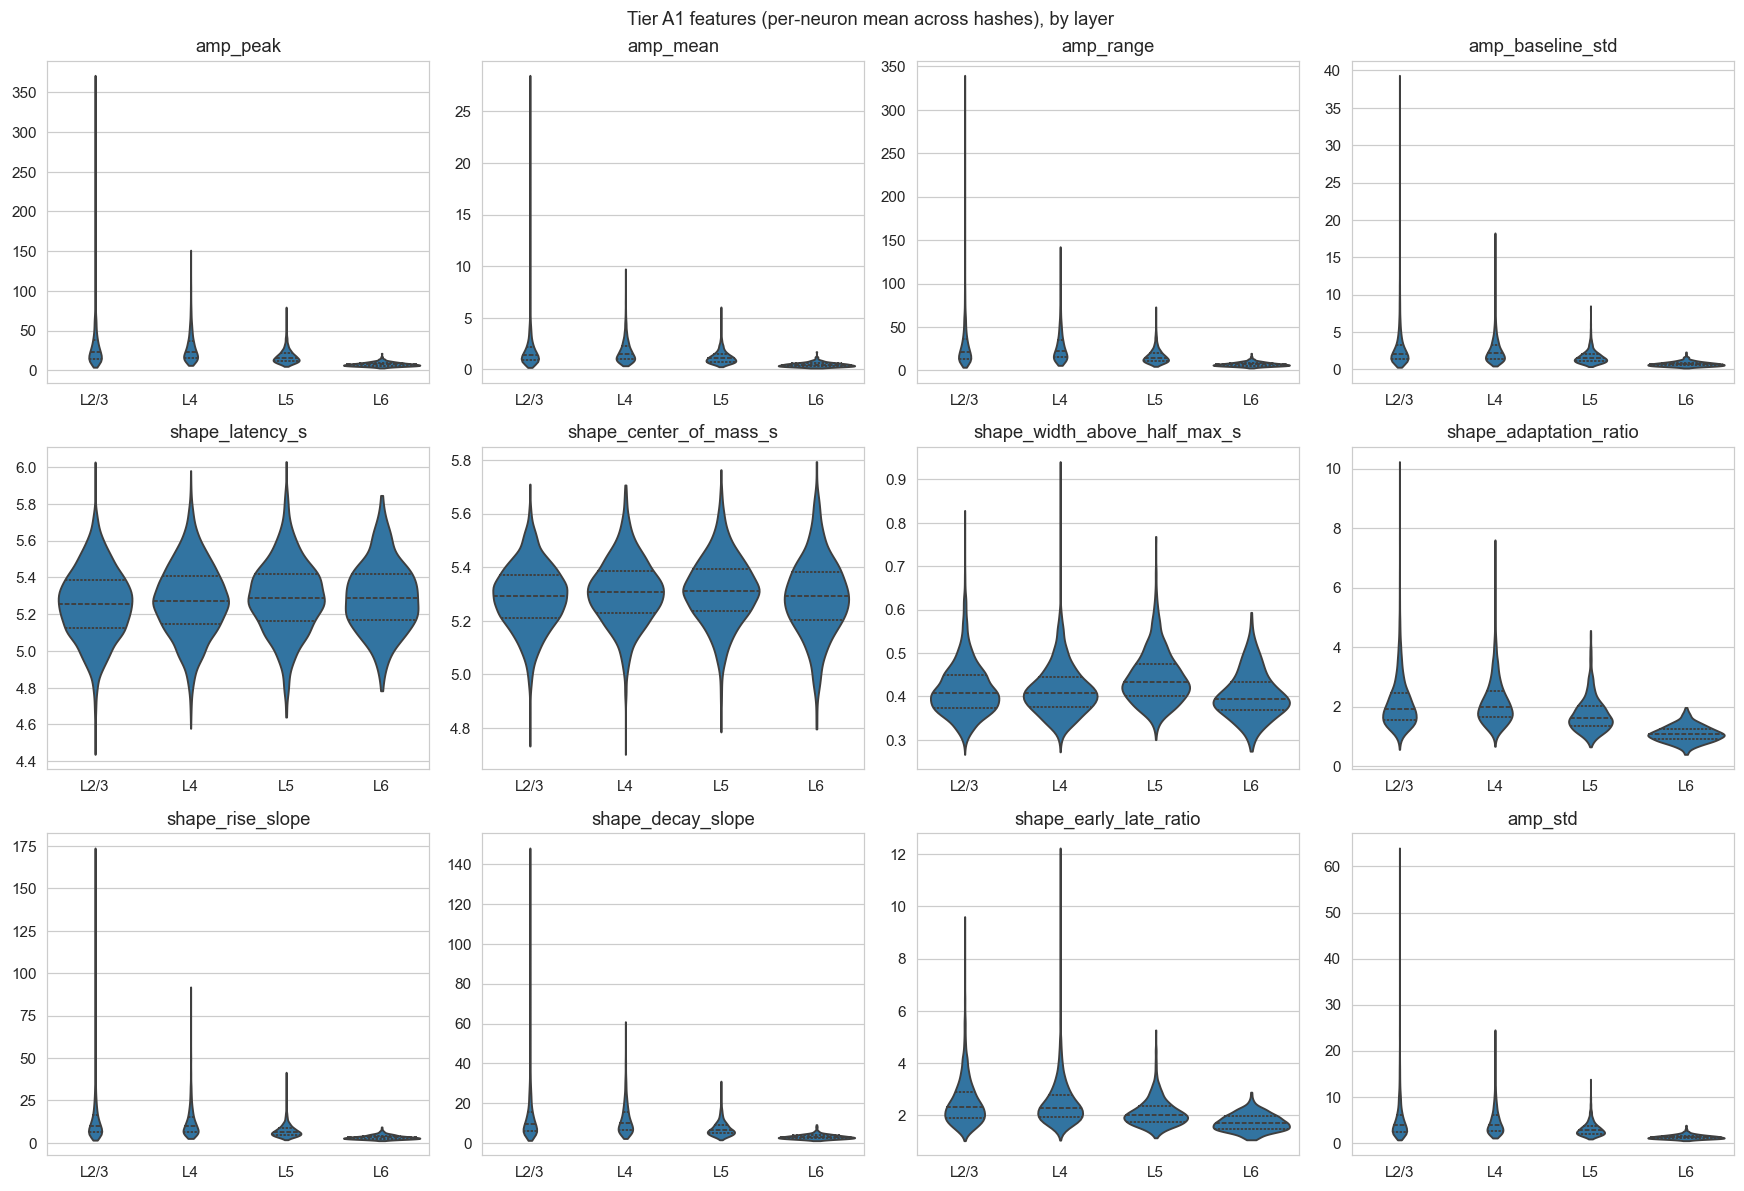

In [6]:
units = pd.read_parquet(PROCESSED_TABLES_DIR / 'units_working.parquet',
                        columns=['nucleus_id', 'layer_label', 'celltype_label', 'cc_abs'])

feats_neuron = (
    pd.merge(A1_amp, A1_shape,
             on=['nucleus_id', 'condition_hash', 'session_key', 'stim_type', 'n_frames', 'n_trials'])
    .groupby('nucleus_id')[list(ALL_FEATURE_NAMES)].mean()
    .reset_index()
    .merge(units, on='nucleus_id')
)
print('per-neuron averaged feature table:', feats_neuron.shape)

show = ['amp_peak', 'amp_mean', 'amp_range', 'amp_baseline_std',
        'shape_latency_s', 'shape_center_of_mass_s',
        'shape_width_above_half_max_s', 'shape_adaptation_ratio',
        'shape_rise_slope', 'shape_decay_slope',
        'shape_early_late_ratio', 'amp_std']
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, feat in zip(axes.flat, show):
    sns.violinplot(data=feats_neuron, x='layer_label', y=feat,
                   order=['L2/3', 'L4', 'L5', 'L6'],
                   inner='quartile', cut=0, ax=ax)
    ax.set_title(feat); ax.set_xlabel(''); ax.set_ylabel('')
plt.suptitle('Tier A1 features (per-neuron mean across hashes), by layer')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_tierA_violins.png', dpi=130)
plt.show()

## 8. Conclusions

Tier A built end-to-end on the full working population:

- `A0_amp.parquet`   — ≈ 4.13M rows × 10 features per `(nucleus_id, trial_idx)`
- `A0_shape.parquet` — ≈ 4.13M rows × 10 features per `(nucleus_id, trial_idx)`
- `A1_amp.parquet`   — ≈ 2.49M rows × 10 features per `(nucleus_id, condition_hash)`
- `A1_shape.parquet` — ≈ 2.49M rows × 10 features per `(nucleus_id, condition_hash)`

**Edge-case handling.** All NaNs in the feature tables are by design and
mark genuinely undefined cases:

- `shape_rise_slope` is NaN when the peak is at frame 0 (latency = 0).
- `shape_decay_slope` is NaN when the peak is at the last frame.
- `shape_early_late_ratio` is NaN when the second-half AUC is `≤ EPS_AUC = 1.0`.
- `shape_adaptation_ratio` is NaN when the first-quartile mean is `≤ EPS_MEAN = 0.1`.
- `shape_center_of_mass_s` is NaN when the trace integral is `≤ EPS_INTEGRAL = 1.0`.
- `shape_width_above_half_max_s` is NaN when the peak is `≤ EPS_PEAK = 0.5`.

Tree models that handle NaN natively (HistGradientBoosting, LightGBM)
consume them directly. Linear models in the modelling notebook (04) wrap
feature input in a median imputer.

**Numerical-stability note.** Earlier iterations of `_safe_div` used a single
global threshold (1e-6) which was correct for raw trace values but let
near-zero denominators of *integrated / averaged* quantities through,
producing ratios up to 1e+9. The current implementation uses biologically-
sized per-quantity thresholds (`EPS_TRACE`, `EPS_MEAN`, `EPS_AUC`,
`EPS_INTEGRAL`, `EPS_PEAK`) — the describe tables above show
`shape_early_late_ratio` and `shape_adaptation_ratio` bounded by
`numerator_max / eps`, which works out to a few thousand and a few hundred
respectively. NaN counts rise as a side effect (those rows had no signal
to make a ratio of); tree models read them directly, linear models impute.

**What `04_phase1_stage1.ipynb` does next.** WORKFLOW §5 Stage 1: layer
decoding from neural-response features only.

- Two parallel pipelines: A0-only (per-trial rows) vs A1-only (per-hash rows).
- Sub-ablation inside each: amp-only vs amp + shape.
- Models: logistic regression (L1/L2), random forest, gradient-boosted trees.
- `StratifiedGroupKFold(5)` by `nucleus_id`, with neuron-level probability
  aggregation at test time (mean of per-row probabilities → argmax).
- §6.5 confound baselines reported alongside: `cc_abs`-only, scan-only,
  cortical-depth-only, plus a `LeaveOneSessionOut` sanity check.
- Headline metric: balanced accuracy at the **neuron** level, with macro F1
  and per-class recall.